# 1). Loading DataSet

⏳ جاري تحميل داتا سيت MNIST...
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 7s 1us/step
✅ تم التحميل بنجاح!
🔹 حجم بيانات التدريب (Images): (60000, 28, 28)
🔹 حجم بيانات الاختبار (Images): (10000, 28, 28)


C:\Users\DELL\AppData\Local\Temp\ipykernel_12084\324542744.py:23: UserWarning: Glyph 128248 (\N{CAMERA WITH FLASH}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\DELL\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128248 (\N{CAMERA WITH FLASH}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


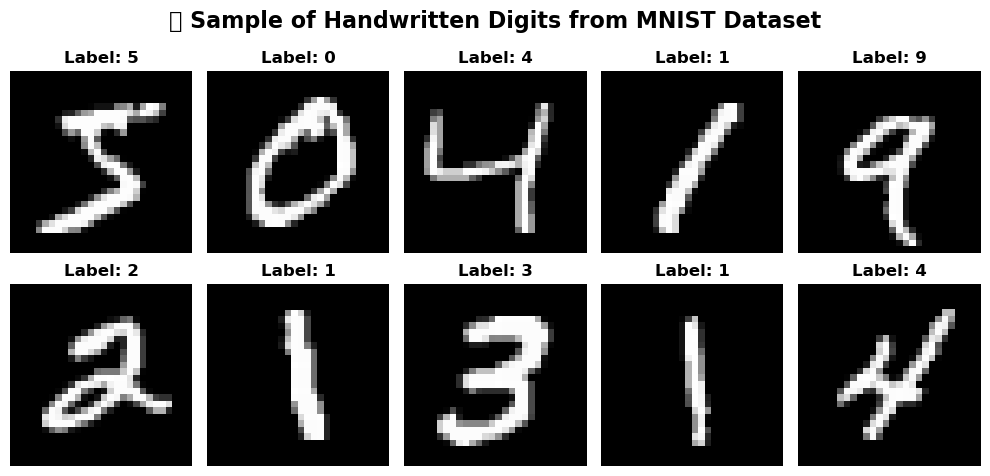

In [1]:
import tensorflow as tf
from tensorflow.keras import datasets
import matplotlib.pyplot as plt
import numpy as np

print("⏳ جاري تحميل داتا سيت MNIST...")
# تحميل البيانات المقسمة تلقائياً لتدريب وتست
(X_train, y_train), (X_test, y_test) = datasets.mnist.load_data()

print(f"✅ تم التحميل بنجاح!")
print(f"🔹 حجم بيانات التدريب (Images): {X_train.shape}")
print(f"🔹 حجم بيانات الاختبار (Images): {X_test.shape}")

# --- عرض عينة من الصور المكتوبة بخط اليد بشكل جذاب ---
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}", fontsize=12, fontweight='bold')
    plt.axis('off')

plt.suptitle("📸 Sample of Handwritten Digits from MNIST Dataset", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# 2). Data Preprocessing

In [2]:
# 1. عمل Normalization لقيم البكسل لتصبح بين 0 و 1
X_train = X_train / 255.0
X_test = X_test / 255.0

# 2. إعادة تشكيل البيانات (Reshape) لإضافة بُعد القناة (Channel = 1 للون الأبيض والأسود)
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

print(f"🔹 الحجم الجديد لبيانات التدريب: {X_train.shape}")
print(f"🔹 الحجم الجديد لبيانات الاختبار: {X_test.shape}")

🔹 الحجم الجديد لبيانات التدريب: (60000, 28, 28, 1)
🔹 الحجم الجديد لبيانات الاختبار: (10000, 28, 28, 1)


# 3). CNN (Model Architecture)

In [3]:
from tensorflow.keras import models, layers

# بناء موديل تتابعي (Sequential)
model = models.Sequential([
    # الطبقة الأولى: Convolutional Layer مع 32 فلتر وحجم 3x3
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    
    # الطبقة الثانية: زيادة الفلاتر لـ 64 لاستخراج ميزات أعقد
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # تحويل المصفوفة ثنائية الأبعاد إلى متجه أحادي (Flatten) تمهيداً للطبقات العادية
    layers.Flatten(),
    
    # طبقة عصبية كثيفة (Dense Layer) تحتوي على 64 نيورون
    layers.Dense(64, activation='relu'),
    
    # طبقة المخرجات (Output Layer): 10 نيورونات (لأن عندنا 10 أرقام) باستخدام Softmax
    layers.Dense(10, activation='softmax')
])

# عمل Compile للموديل وتحديد الـ Optimizer والـ Loss Function
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# عرض ملخص شكل المعمارية (Summary)
model.summary()

C:\Users\DELL\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │         102,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

# 4). Model Training

In [4]:
# تدريب الموديل وحفظ تاريخ التدريب في متغير تاريخ (history) لرسمه لاحقاً
print("🚀 جاري بدء تدريب الشبكة العصبية الالتفافية (CNN)...")
history = model.fit(X_train, y_train, 
                    epochs=5, 
                    batch_size=64, 
                    validation_data=(X_test, y_test))

print("✅ انتهى التدريب بنجاح!")

🚀 جاري بدء تدريب الشبكة العصبية الالتفافية (CNN)...
Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 18s 17ms/step - accuracy: 0.9491 - loss: 0.1689 - val_accuracy: 0.9797 - val_loss: 0.0638
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 16s 17ms/step - accuracy: 0.9837 - loss: 0.0528 - val_accuracy: 0.9861 - val_loss: 0.0405
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 16s 17ms/step - accuracy: 0.9892 - loss: 0.0364 - val_accuracy: 0.9884 - val_loss: 0.0334
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 16s 17ms/step - accuracy: 0.9916 - loss: 0.0276 - val_accuracy: 0.9886 - val_loss: 0.0312
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 17s 18ms/step - accuracy: 0.9933 - loss: 0.0207 - val_accuracy: 0.9888 - val_loss: 0.0322
✅ انتهى التدريب بنجاح!


# 5). Evaluation & Visualization


🎯 الدقة النهائية للموديل على بيانات الاختبار: 98.88%


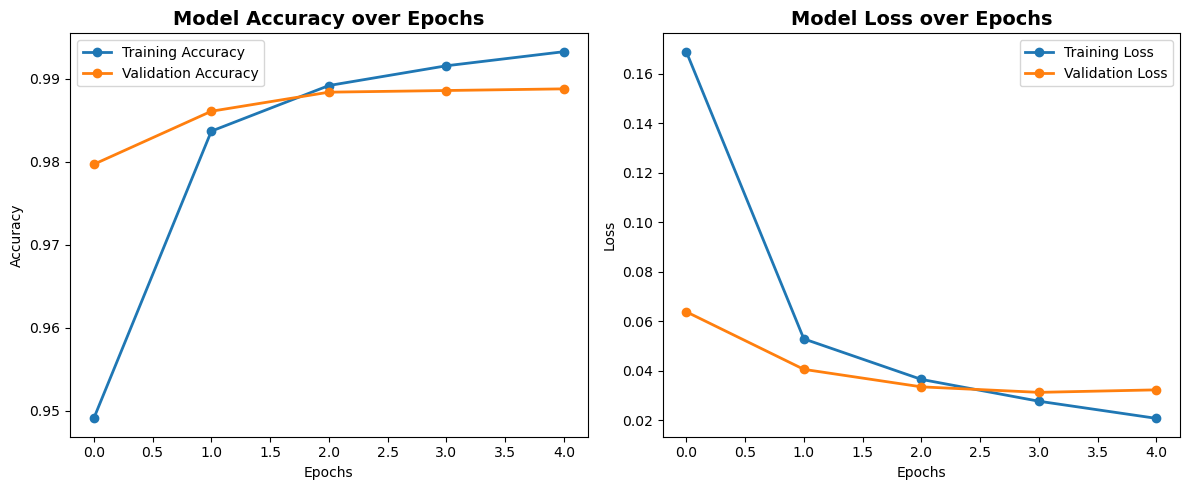

In [5]:
# 1. حساب الدقة على بيانات الاختبار (Test Dataset)
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\n🎯 الدقة النهائية للموديل على بيانات الاختبار: {test_acc*100:.2f}%")

# 2. رسم منحنيات الدقة والخطأ بشكل جذاب
plt.figure(figsize=(12, 5))

# رسم منحنى الدقة (Accuracy)
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2, marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2, marker='o')
plt.title('Model Accuracy over Epochs', fontsize=14, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# رسم منحنى الخطأ (Loss)
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', linewidth=2, marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2, marker='o')
plt.title('Model Loss over Epochs', fontsize=14, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# 6). Prediction Check

In [6]:
# اختيار الصورة الأولى من بيانات الاختبار وعرض تخمين الموديل لها
predictions = model.predict(X_test[:1])
predicted_label = np.argmax(predictions)
true_label = y_test[0]

print(f"\n🔮 تخمين الموديل للصورة الأولى: {predicted_label}")
print(f"✅ الرقم الحقيقي في الصورة: {true_label}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step

🔮 تخمين الموديل للصورة الأولى: 7
✅ الرقم الحقيقي في الصورة: 7


⏳ جاري حساب التوقعات لبيانات الاختبار...
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


C:\Users\DELL\AppData\Local\Temp\ipykernel_12084\2317114258.py:29: UserWarning: Glyph 128302 (\N{CRYSTAL BALL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\DELL\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128302 (\N{CRYSTAL BALL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


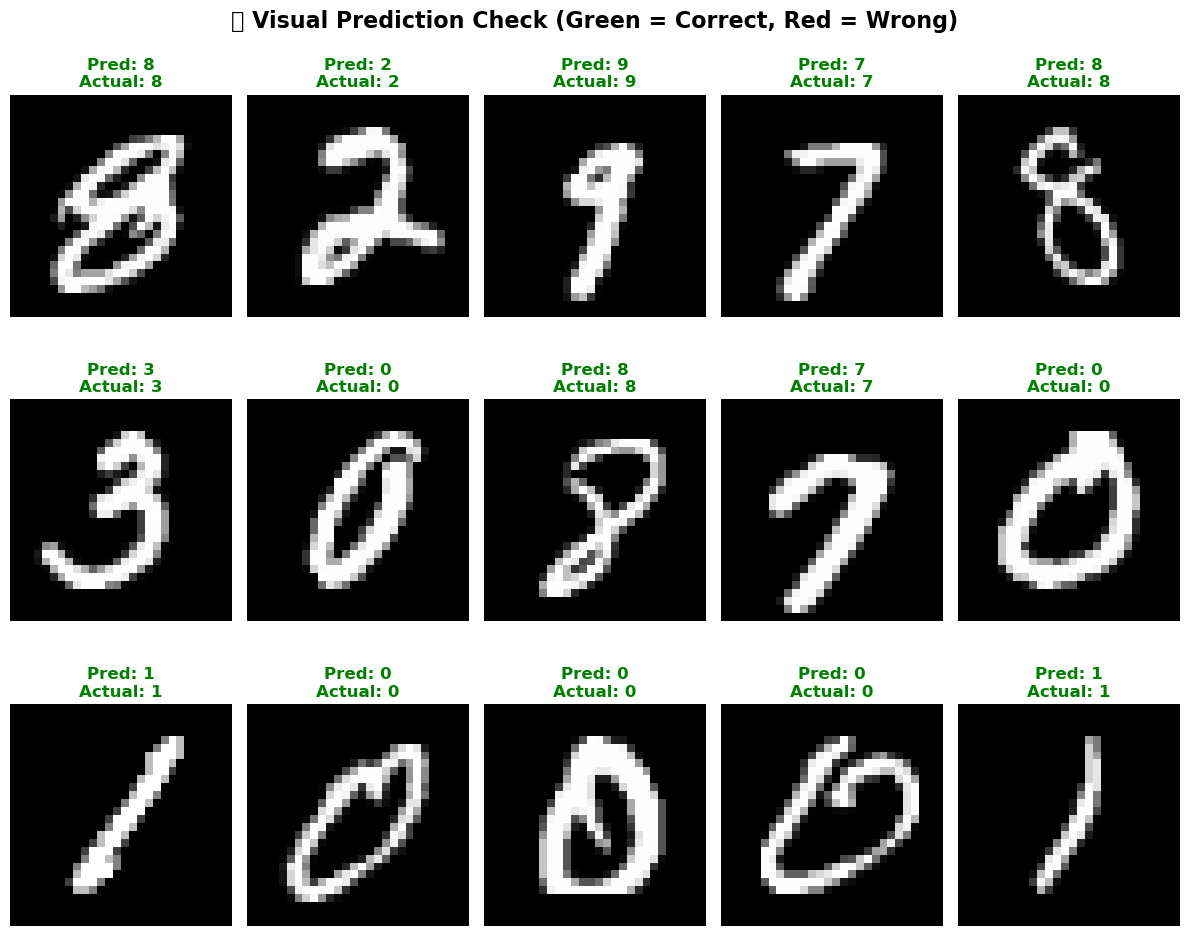


📜 تقرير الأداء المفصل لكل رقم من (0 إلى 9):
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       0.99      1.00      0.99      1135
           2       0.99      0.99      0.99      1032
           3       0.99      1.00      0.99      1010
           4       0.97      1.00      0.99       982
           5       0.99      0.99      0.99       892
           6       1.00      0.98      0.99       958
           7       0.98      0.99      0.99      1028
           8       0.99      0.98      0.99       974
           9       0.99      0.96      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000


📊 جاري رسم Confusion Matrix لمعرفة الأرقام المتشابهة...


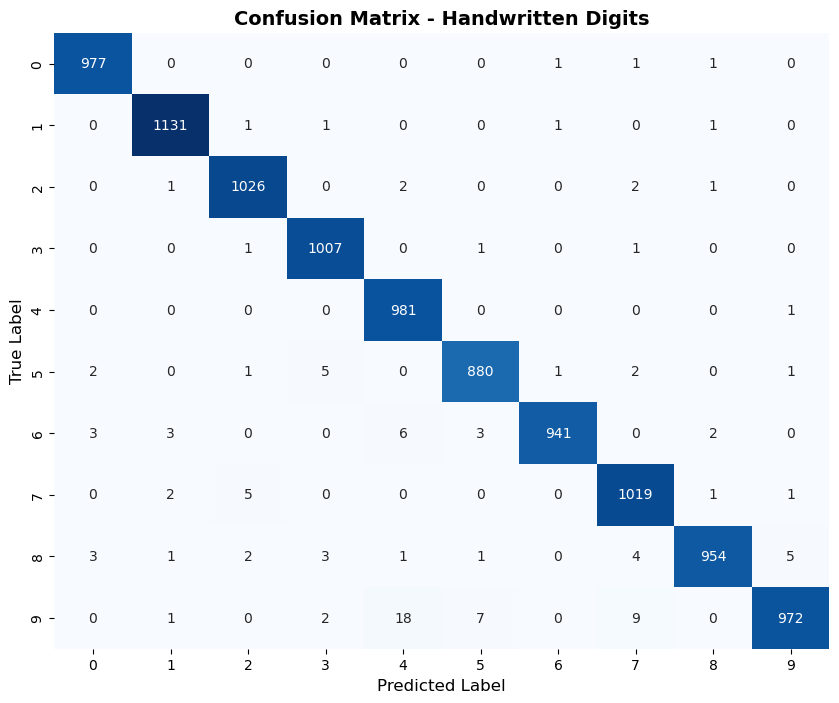

In [7]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# --- 1. التنبؤ على كل بيانات الاختبار ---
print("⏳ جاري حساب التوقعات لبيانات الاختبار...")
y_pred_proba = model.predict(X_test)
y_pred = np.argmax(y_pred_proba, axis=1)

# --- 2. عرض مصفوفة صور عشوائية مع التوقعات (Grid of Predictions) ---
plt.figure(figsize=(12, 10))
# اختار 15 دليل عشوائي من بيانات التست
random_indices = np.random.choice(len(X_test), size=15, replace=False)

for i, idx in enumerate(random_indices):
    plt.subplot(3, 5, i + 1)
    # إعادة الصورة لشكلها الأصلي للعرض (28x28)
    plt.imshow(X_test[idx].reshape(28, 28), cmap='gray')
    
    pred = y_pred[idx]
    actual = y_test[idx]
    
    # تحديد لون النص: أخضر لو التوقع صح، أحمر لو غلط
    color = 'green' if pred == actual else 'red'
    
    plt.title(f"Pred: {pred}\nActual: {actual}", color=color, fontsize=12, fontweight='bold')
    plt.axis('off')

plt.suptitle("🔮 Visual Prediction Check (Green = Correct, Red = Wrong)", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# --- 3. طباعة تقرير الأداء الشامل لكل رقم (Classification Report) ---
print("\n📜 تقرير الأداء المفصل لكل رقم من (0 إلى 9):")
print(classification_report(y_test, y_pred))

# --- 4. رسم مصفوفة الارتباك (Confusion Matrix) ---
print("\n📊 جاري رسم Confusion Matrix لمعرفة الأرقام المتشابهة...")
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix - Handwritten Digits', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.show()

# 7) Save Modeling

In [8]:
# حفظ الموديل بالكامل (المعمارية والأوزان)
model.save('handwritten_digits_cnn_model.keras')
print("✅ تم حفظ موديل الـ CNN بنجاح باسم 'handwritten_digits_cnn_model.keras'")

✅ تم حفظ موديل الـ CNN بنجاح باسم 'handwritten_digits_cnn_model.keras'
